In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint
from joblib import Parallel, delayed
import ast

from sklearn.feature_selection import SelectFromModel, mutual_info_classif, f_classif, SelectKBest
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


import sys
init_dir = os.getcwd()  

In [4]:
consumer_df = pd.read_parquet(init_dir + '/cashflow-data/consumer_data.parquet')
transactions = pd.read_parquet(init_dir + '/cashflow-data/transactions.parquet')

In [5]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date', 'FPF_TARGET']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]
transactions_df['month'] = transactions_df['posted_date'].dt.to_period('M')
transactions_df['posted_date'] = pd.to_datetime(transactions_df['posted_date'])
transactions_df['converted_date'] = (max(transactions_df['posted_date']) - transactions_df['posted_date']).dt.total_seconds()/3600
transactions_df = transactions_df[transactions_df['masked_consumer_id'].str[2].isin(['1', '4'])]


In [6]:
# import pandas as pd

# def process_user_parallel(user_id, group, ranges=24*7, num_categories=36):
#     start = group['converted_date'].min()
#     end = group['converted_date'].max()

#     segments = []
#     for x in range(int(start), int(end), ranges):
#         mask = group[(group['converted_date'] >= x) & (group['converted_date'] < x + ranges)]
#         if len(mask) == 0 or (mask['converted_date'].min() + ranges >  end):
#             continue

#         data = {
#             'net_week_series': mask['amount'].sum(),
#             'count_week_series': mask['amount'].count(),
#             'inflow_week_series': mask[mask['amount'] > 0]['amount'].sum(),
#             'outflow_week_series': mask[mask['amount'] < 0]['amount'].sum(),
#         }
#         for i in range(num_categories):
#             data[f"week_series_category_{i}"] = mask[mask['category'] == i]['amount'].sum()
#         segments.append(data)

#     if len(segments) == 0:
#         return user_id, pd.Series({
#             key: [0] 
#             for key in ['net_week_series', 'count_week_series', 'inflow_week_series', 'outflow_week_series'] +
#                        [f"week_series_category_{i}" for i in range(num_categories)]
#         })

#     segments = segments[::-1]
#     output = {key: [seg[key] for seg in segments] for key in segments[0].keys()}
#     return user_id, pd.Series(output)

# # Split by user 
# grouped = list(df_4.groupby('masked_consumer_id'))

# # Parallel processing
# results = Parallel(n_jobs=-1)(delayed(process_user_parallel)(uid, grp) for uid, grp in grouped)

# # Combine results
# transaction_grouped = pd.DataFrame({uid: out for uid, out in results}).T.reset_index().rename(columns={'index': 'masked_consumer_id'})
# transaction_grouped.set_index('masked_consumer_id').to_csv(init_dir + '/cashflow-data/features.csv')

In [7]:
def make_transaction_features(transactions):
    tx = transactions.copy()

    # Create debit/credit indicators
    tx['is_credit'] = tx['amount'] > 0
    tx['is_debit'] = tx['amount'] < 0

    # Basic aggregate features
    agg = tx.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('is_credit', lambda x: tx.loc[x.index, 'amount'][x].sum()),
        debit_sum=('is_debit', lambda x: abs(tx.loc[x.index, 'amount'][x].sum()))
    )
    agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
    agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

    # Recent 30-day features
    tx['days_before_eval'] = (tx['evaluation_date'] - tx['posted_date']).dt.days
    recent_df = tx[tx['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
        recent30_sum=('amount', 'sum'),
        recent30_count=('amount', 'count'),
        recent30_std=('amount', 'std')
    )
    # Monthly volatility
    tx['month'] = tx['posted_date'].dt.to_period('M')
    tx["day"] = tx["posted_date"].dt.day.astype(int)
    tx["DoY"] = tx["evaluation_date"].dt.dayofyear.astype(int)
    monthly_cashflow = tx.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
        columns={'mean': 'monthly_mean', 'std': 'monthly_std'})
    monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan) # coefficient of variation
    monthly_stats = monthly_stats.fillna(0)
    monthly_stats["weighted_avg_day"] = abs(15.5-tx.groupby(['masked_consumer_id']).apply(lambda g: (g["day"] * abs(g["amount"])).sum() / abs(g["amount"]).sum()))
    monthly_stats["DoY"] = tx.groupby(["masked_consumer_id"])["DoY"].mean()

    # Weekend spending
    tx['weekday'] = tx['posted_date'].dt.weekday
    tx['is_weekend'] = tx['weekday'] >= 5
    # Calculate weekend and weekday spending separately
    weekend_spend = tx[tx['amount'] > 0].groupby('masked_consumer_id').agg(
        weekday_spending=('amount', lambda x: x[~tx.loc[x.index, 'is_weekend']].sum()),
        weekend_spending=('amount', lambda x: x[tx.loc[x.index, 'is_weekend']].sum())
    )
    weekend_spend["weighted_avg_weekday"] = tx.groupby(['masked_consumer_id']).apply(lambda g: (g["weekday"] * abs(g["amount"])).sum() / abs(g["amount"]).sum())
    weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

    # Transaction frequency
    txn_freq = tx.groupby('masked_consumer_id').agg(
        unique_txn_days=('posted_date', lambda x: x.nunique()),
        txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
    )
    txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

    # Percentiles
    percentiles = tx.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
    percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

    # Large transactions
    tx['is_large'] = tx['amount'].abs() > 400
    large_txns = tx.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

    # Monthly trend
    monthly_spend = tx.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()

    def compute_monthly_trend(df):
        if df.shape[0] < 2:
            return 0
        df = df.sort_values('month')
        x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
        y = df['amount'].values
        model = LinearRegression().fit(x, y)
        return model.coef_[0]

    monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

    # Category encoding
    cat_encode = pd.get_dummies(tx, columns=['category'], drop_first=False)
    cat_cols = [col for col in cat_encode.columns if col.startswith('category_')]
    cat_encode_mean = cat_encode.groupby('masked_consumer_id')[cat_cols].sum()

    # Category-Specific Spending
    cat_spending = tx.pivot_table(index='masked_consumer_id', columns='category', values='amount', aggfunc='sum', fill_value=0)
    cat_spending.columns = [f'spend_cat_{int(c)}' for c in cat_spending.columns]

    # Credit-Debit Gap per Category
    def credit_debit_gap(df):
        pos = df[df['amount'] > 0].groupby('category')['amount'].sum()
        neg = df[df['amount'] < 0].groupby('category')['amount'].sum().abs()
        return (pos - neg).fillna(0)

    gap_df = tx.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)

    # Binary Category Usage
    usage = pd.crosstab(tx['masked_consumer_id'], tx['category']).astype(bool).astype(int)
    usage.columns = [f'used_cat_{int(c)}' for c in usage.columns]

    # Timing Features per Category
    cat_days = tx.groupby(['masked_consumer_id', 'category'])['posted_date'].agg(['min', 'max', 'count'])
    cat_days['duration'] = (cat_days['max'] - cat_days['min']).dt.days
    cat_days['txn_gap'] = cat_days['duration'] / cat_days['count'].replace(0, 1)
    duration_feat = cat_days['txn_gap'].unstack().fillna(0).add_prefix('gap_days_cat_')

    # Merge all features
    features_df = agg \
        .join(recent_df, how='left') \
        .join(monthly_stats, how='left') \
        .join(txn_freq, how='left') \
        .join(weekend_spend, how='left') \
        .join(large_txns, how='left') \
        .join(percentiles, how='left') \
        .join(monthly_trend, how='left') \
        .join(cat_encode_mean, how='left') \
        .join(gap_df, how='left') \
        .join(usage, how='left') \
        .join(duration_feat, how='left') \
        .fillna(0) \
        .reset_index()

    return features_df

In [8]:
def make_weekly_features(
    transactions,
    top_categories=None,
    include_cv=True,
    include_trend=True,
    include_rolling=True,
    include_weekend=True
):
    tx = transactions.copy()
    tx['week'] = tx['posted_date'].dt.to_period('W').apply(lambda r: r.start_time)

    if top_categories is None:
        top_categories = tx['category'].value_counts().nlargest(35).index.tolist()
    tx = tx[tx['category'].isin(top_categories)]

    # Base weekly aggregation
    weekly_stats = tx.groupby(['masked_consumer_id', 'category', 'week'])['amount'].agg(['sum', 'mean', 'std', 'count']).reset_index()
    weekly_stats = weekly_stats.sort_values(['masked_consumer_id', 'category', 'week'])

    if include_rolling:
        weekly_stats['rolling_mean'] = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].transform(lambda x: x.rolling(3, min_periods=1).mean())
        weekly_stats['rolling_std'] = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))
        weekly_stats['weekly_change'] = (
            weekly_stats.groupby(['masked_consumer_id', 'category'])['sum']
            .pct_change()
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

    if include_cv:
        cat_volatility = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].agg(['std', 'mean'])
        cat_volatility['cv'] = cat_volatility['std'] / cat_volatility['mean'].replace(0, np.nan)
        cat_volatility = cat_volatility.unstack().fillna(0)
        cat_volatility.columns = [f'weekly_cat_{stat}_{int(cat)}' for stat, cat in cat_volatility.columns]
    else:
        cat_volatility = None

    if include_trend:
        def compute_weekly_trend(df):
            if df.shape[0] < 2:
                return 0
            df = df.sort_values('week')
            x = (df['week'] - df['week'].min()).dt.days.values.reshape(-1, 1)
            y = df['sum'].values
            model = LinearRegression().fit(x, y)
            return model.coef_[0]

        cat_trends = weekly_stats.groupby(['masked_consumer_id', 'category']).apply(compute_weekly_trend).unstack().fillna(0)
        cat_trends.columns = [f'weekly_trend_cat_{int(c)}' for c in cat_trends.columns]
    else:
        cat_trends = None

    if include_weekend:
        tx['weekday'] = tx['posted_date'].dt.weekday
        tx['is_weekend'] = tx['weekday'] >= 5
        cat_weekend = tx.groupby(['masked_consumer_id', 'category']).apply(
            lambda df: df[df['is_weekend']]['amount'].sum() / (df[~df['is_weekend']]['amount'].sum() + 1e-6)
        ).unstack().fillna(0)
        cat_weekend.columns = [f'weekend_ratio_cat_{int(c)}' for c in cat_weekend.columns]
    else:
        cat_weekend = None

    agg_dict = {}
    if include_rolling:
        agg_dict.update({
            'rolling_mean': 'mean',
            'rolling_std': 'mean',
            'weekly_change': ['mean', 'std']
        })
    agg_dict['count'] = 'mean'

    if agg_dict:
        feats = weekly_stats.groupby(['masked_consumer_id', 'category']).agg(agg_dict)
        feats.columns = [f'{col}_{stat}' for col, stat in feats.columns]
        feats = feats.unstack(level=1).fillna(0)
        feats.columns = [f'{col}_cat_{int(cat)}' for col, cat in feats.columns]
    else:
        feats = pd.DataFrame(index=weekly_stats['masked_consumer_id'].unique())

    final_feats = feats.reset_index()

    if include_cv and cat_volatility is not None:
        final_feats = final_feats.merge(cat_volatility.reset_index(), on='masked_consumer_id', how='left')
    if include_trend and cat_trends is not None:
        final_feats = final_feats.merge(cat_trends.reset_index(), on='masked_consumer_id', how='left')
    if include_weekend and cat_weekend is not None:
        final_feats = final_feats.merge(cat_weekend.reset_index(), on='masked_consumer_id', how='left')

    final_feats = final_feats.fillna(0)

    # Normalize all non-ratio features by total transaction amount per user
    total_spent = tx.groupby('masked_consumer_id')['amount'].sum().rename('total_spent')
    final_feats = final_feats.merge(total_spent, on='masked_consumer_id', how='left')

    trend_cols = [col for col in final_feats.columns if col.startswith('weekly_trend_cat_')]
    for col in trend_cols:
        final_feats[col] = final_feats[col] / (final_feats['total_spent'] + 1e-6)

    final_feats = final_feats.drop(columns='total_spent')

    return final_feats


In [9]:
trans_features = make_transaction_features(transactions_df)
weekly_features = make_weekly_features(transactions_df)
weekly_features['masked_consumer_id'] = weekly_features['masked_consumer_id'].astype(str)
trans_features['masked_consumer_id'] = trans_features['masked_consumer_id'].astype(str)
features_df = weekly_features.merge(trans_features, how='left', on='masked_consumer_id')
features_df = features_df.merge(consumer_df[['masked_consumer_id', 'FPF_TARGET']],on='masked_consumer_id',how='left')
features_df

C:\Users\manat\AppData\Local\Temp\ipykernel_35616\1606057441.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_stats["weighted_avg_day"] = abs(15.5-tx.groupby(['masked_consumer_id']).apply(lambda g: (g["day"] * abs(g["amount"])).sum() / abs(g["amount"]).sum()))
C:\Users\manat\AppData\Local\Temp\ipykernel_35616\1606057441.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekend_spend["weighted

,masked_consumer_id,rolling_mean_mean_cat_0,rolling_mean_mean_cat_1,rolling_mean_mean_cat_2,rolling_mean_mean_cat_3,rolling_mean_mean_cat_4,rolling_mean_mean_cat_5,rolling_mean_mean_cat_6,rolling_mean_mean_cat_7,rolling_mean_mean_cat_8,...,gap_days_cat_28.0,gap_days_cat_29.0,gap_days_cat_30.0,gap_days_cat_31.0,gap_days_cat_32.0,gap_days_cat_33.0,gap_days_cat_34.0,gap_days_cat_35.0,gap_days_cat_36.0,FPF_TARGET
0,C01100001,2959.125986,-3237.910680,1106.981505,1927.633056,1149.116111,1726.005000,64.437500,637.828846,1889.625000,...,11.269231,1.0,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0
1,C01100002,78.750000,-267.028021,1681.412043,1688.276569,3186.513708,775.405139,0.000000,0.108194,0.000000,...,0.000000,0.0,82.666667,0.0,0.0,0.0,0.00,0.0,0.0,0.0
2,C01100003,239.972167,-187.912708,564.835758,2865.333000,0.000000,0.000000,0.000000,0.045694,0.000000,...,22.500000,0.0,21.666667,0.0,0.0,0.0,26.25,0.0,0.0,0.0
3,C01100004,999.919048,-847.962721,341.576825,0.000000,33.410256,0.000000,22.980000,0.010000,1242.583333,...,51.000000,0.0,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0
4,C01100005,-534.982500,-782.236090,252.144848,0.000000,4133.707853,0.000000,47.838462,1.260952,0.000000,...,17.687500,0.0,25.769231,0.0,0.0,0.0,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,C04104996,187.724638,-51.150000,690.886389,730.632917,596.868333,662.435079,55.145000,0.000000,0.000000,...,42.166667,35.7,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0
7995,C04104997,208.569444,-175.767812,331.140000,3536.986111,0.000000,0.000000,60.282833,0.000000,0.000000,...,19.454545,62.6,55.500000,0.0,0.0,0.0,0.00,86.5,0.0,0.0
7996,C04104998,198.258611,-134.149516,1400.000000,3525.356067,575.000000,0.000000,46.424848,0.000000,0.000000,...,23.615385,0.0,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0
7997,C04104999,5854.610667,594.811895,2757.508710,484.255530,197.536204,0.000000,74.797000,0.000000,1112.272727,...,0.000000,0.0,0.000000,0.0,0.0,0.0,22.50,0.0,0.0,0.0


In [10]:
features_df.merge(fft_features_df, on='masked_consumer_id', how='left')

NameError: name 'fft_features_df' is not defined

In [ ]:
def select_features_pipeline(X, y, top_k=150):
    # Initial filtering with ANOVA and Mutual Information
    anova_selector = SelectKBest(f_classif, k=top_k).fit(X, y)
    mi_selector = SelectKBest(mutual_info_classif, k=top_k).fit(X, y)

    # union of both methods
    selected_features = list(set(X.columns[anova_selector.get_support()]) | set(X.columns[mi_selector.get_support()]))

    X_filtered = X[selected_features]

    # XGBoost CV for stable importance
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    feature_importances = []

    for train_idx, val_idx in skf.split(X_filtered, y):
        model = XGBClassifier()
        model.fit(X_filtered.iloc[train_idx], y.iloc[train_idx])
        feature_importances.append(model.feature_importances_)

    avg_importance = np.mean(feature_importances, axis=0)
    importance_df = pd.DataFrame({
        'feature': X_filtered.columns,
        'importance': avg_importance
    }).sort_values(by='importance', ascending=False)

    # Final Selection: keep features with importance above median
    median_importance = importance_df['importance'].median()/2
    final_features = importance_df[importance_df['importance'] > median_importance]['feature'].tolist()

    return final_features

In [ ]:
features2_df = features_df[features_df['masked_consumer_id'].str[2] == '4']
X = features2_df.set_index('masked_consumer_id').drop(columns=['FPF_TARGET',])
y = features2_df['FPF_TARGET']
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.20, ) 
X_val = X_val.fillna(0).replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(0).replace([np.inf, -np.inf], np.nan)

In [ ]:
# Step 7: Model Training and Evaluation
def model_training_and_evaluation(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_train_pred = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_train_pred)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_proba) 
    print(f"Training AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define parameter grid including scale_pos_weight
param_grid = {
    'max_depth': [3, 6, 10, 50],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0.1, 1, 10, 50],
    'scale_pos_weight': [1, 2, 5, 10, 20]  # Adjust this based on class imbalance
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='auc')

# Randomized search
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    n_jobs=-1,
    cv=3,
    verbose=1,
)

# Fit search to training data
random_search.fit(X_train, y_train)

# Best model
xgb_tuned = random_search.best_estimator_

# Evaluate best model
print("Best parameters found:", random_search.best_params_)
model_training_and_evaluation(xgb_tuned, X_train, y_train, X_val, y_val)


Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\manat\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:10:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters found: {'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 50, 'reg_alpha': 10, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}


c:\Users\manat\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:10:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training AUC: 0.9628, Validation AUC: 0.6966


In [ ]:
X_val2 = X_val.reset_index()
X_val2 = X_val2[X_val2['masked_consumer_id'].str[2] == '4'].drop(columns=['masked_consumer_id'])
y_val2 = y_val.reset_index(drop=True)[X_val2.index]
val2_auc = roc_auc_score(y_val2, xgb_tuned.predict_proba(X_val2)[:, 1])
val2_auc

0.6966089466089466

In [ ]:
(xgb_tuned.predict(X_val2)).sum()

0

In [ ]:
# Step 8: Feature Importance
def feature_importance(model, X_train):
    if hasattr(model, 'named_steps'):
        model_name = model.named_steps['model'].__class__.__name__.lower()
        base_model = model.named_steps['model']
    else:
        model_name = model.__class__.__name__.lower()
        base_model = model

    # Return importances based on type
    if 'xgb' in model_name:
        importances = base_model.feature_importances_
    elif 'logistic' in model_name:
        importances= base_model.coef_[0]
    else:
        raise NotImplementedError(f"Model type '{model_name}' not supported.")

    feature_importance = pd.DataFrame({
        'feature': X_train.columns, 
        'importance': importances
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    # Display top features
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

    # Optional: Visualize feature importance
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.title('Top 10 Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


Top 10 Most Important Features:
                      feature  importance
184          weekly_cat_std_9    0.021580
105   weekly_change_std_cat_0    0.012911
254           weekly_cat_cv_9    0.012121
58    rolling_std_mean_cat_23    0.011552
355             median_amount    0.011434
298       weekly_trend_cat_18    0.009977
132  weekly_change_std_cat_27    0.009665
365                monthly_cv    0.009537
45    rolling_std_mean_cat_10    0.009488
402             category_22.0    0.008769


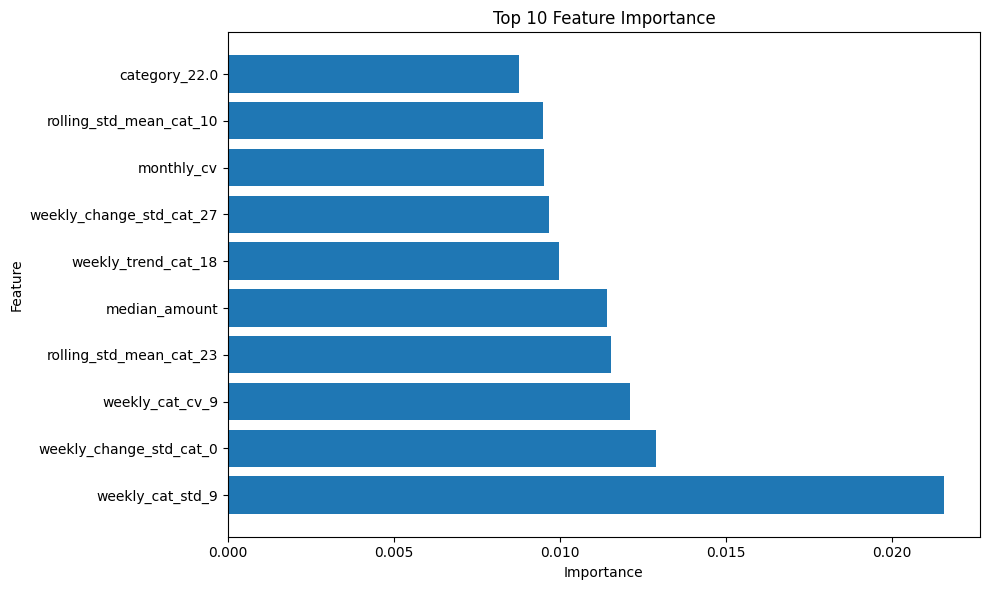

In [ ]:
feature_importance(xgb_tuned, X_train)

In [ ]:
xgb_tuned.save_model("model04.json")

In [ ]:
import xgboost as xgb
model = xgb.Booster({'nthread': 4})
model.load_model('./models/model04.json')

In [13]:
(consumer_df['masked_consumer_id'] == 'C04104406').sum()

1